# Pha U — S1b: kiểm tra ĐỘ TIN CẬY của kết quả thích nghi (lr 1e-3)

Ở `phase_u_01`, lr=1e-3 cho đúng chiều RSA ở 17/17 bản ghi nhưng Spearman vs KSG ≈ 0 → nghi là **độ lệch hằng số giữa 2 chiều**, không phải TE theo từng bản ghi.

Hai kiểm tra (khai báo trước, không chỉnh siêu tham số; chỉ lr=1e-3, 5 epoch như cũ):
1. **Đa seed** (3 cách chia fold khác nhau): kết quả có ổn định không, Spearman vs KSG có dương rõ không.
2. **Đối chứng surrogate:** xáo trộn x_lag trong từng cửa sổ (phá ghép nối tim–hô hấp, giữ nguyên phân phối biên), rồi thích nghi + đánh giá y hệt. TE thật ≈ 0 ở cả 2 chiều. Nếu vẫn ra "đúng chiều 17/17" thì kết quả là **artifact**.

Tiêu chí G1' (thêm SAU khi thấy kết quả u01, nêu rõ trong báo cáo): qua chỉ khi mọi seed có Spearman vs KSG ≥ 0.3 VÀ surrogate không cho chênh lệch dương tương đương thật (|mean_diff surrogate| < 0.5 × mean_diff thật).

Ước tính chạy: khoảng 2 lần thời gian của u01 (4 lượt thích nghi). Tắt sleep.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, time, dataclasses
os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Java\jdk-22')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from pathlib import Path
from scipy.stats import spearmanr

from pqrst.data.synthetic.corpus import load_corpus
from pqrst.estimators.mine.amortized import AmortizedTEEstimator
from pqrst.estimators.mine.adapt import adapt_amortized, make_record_folds
from pqrst.baselines.ksg import KSGTEEstimator
from pqrst.evaluation.sanity_check import bidirectional_te_per_record

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
K_FOLDS=4; LR=1e-3; EPOCHS=5; CAP=100; SEEDS=[0,1,2]

In [2]:
proc_dir = BASE/'data'/'processed'/'fantasia'
quality = pd.read_csv(proc_dir/'quality_report.csv')
passed = quality.loc[quality['verdict']=='PASS','record_id'].tolist()
records = {r:(load_corpus(str(proc_dir/(r+'_bwd.npz'))), load_corpus(str(proc_dir/(r+'_fwd.npz')))) for r in passed}
ids=list(records); print(len(ids),'ban ghi')
base = AmortizedTEEstimator.load(str(BASE/'results'/'checkpoints'/'phi_amortized_standardized.pt'))
def diffs_of(d): return np.array([d[r]['te_forward']-d[r]['te_backward'] for r in ids])
ksg = bidirectional_te_per_record(records, KSGTEEstimator()); d_ksg=diffs_of(ksg)
print('KSG dung chieu:', (d_ksg>0).mean())

def surrogate(ws, rng):
    return [dataclasses.replace(w, x_lag=rng.permutation(w.x_lag)) for w in ws]
def sample(ws,n,rng):
    if len(ws)<=n: return list(ws)
    return [ws[i] for i in rng.choice(len(ws),n,replace=False)]

def run(recs, seed):
    folds=make_record_folds(list(recs), K_FOLDS, seed=seed); rng=np.random.default_rng(seed); out={}
    for fi,held in enumerate(folds):
        tr=[r for r in recs if r not in held]; val_id,ad=tr[0],tr[1:]
        aw=[w for r in ad for d in (0,1) for w in sample(recs[r][d],CAP,rng)]
        vw=[w for d in (0,1) for w in sample(recs[val_id][d],40,rng)]
        est,h=adapt_amortized(base,aw,vw,learning_rate=LR,max_epochs=EPOCHS,seed=seed*100+fi)
        out.update(bidirectional_te_per_record({r:recs[r] for r in held},est))
        print(f'  fold {fi} xong, val_loss {h["val_loss_history"][0]:.3f}->{h["val_loss_history"][-1]:.3f}')
    return out

17 ban ghi
KSG dung chieu: 0.8235294117647058


## 1. Đa seed trên dữ liệu thật

In [3]:
rows=[]; real={}
for s in SEEDS:
    t0=time.time(); print('seed',s)
    real[s]=run(records,s); d=diffs_of(real[s])
    rho=spearmanr(d,d_ksg)[0]
    rows.append(dict(kind='real',seed=s,mean_diff=d.mean(),sd_diff=d.std(ddof=1),frac_correct_dir=(d>0).mean(),spearman_vs_KSG=rho))
    print(f'  {time.time()-t0:.0f}s | mean_diff={d.mean():.4f} sd={d.std(ddof=1):.4f} dung chieu={(d>0).mean():.2f} rho={rho:.3f}')

seed 0
  fold 0 xong, val_loss -0.796->-0.872
  fold 1 xong, val_loss -0.953->-0.922
  fold 2 xong, val_loss -0.973->-0.930
  fold 3 xong, val_loss -0.951->-0.919
  442s | mean_diff=0.0477 sd=0.0232 dung chieu=1.00 rho=-0.017
seed 1
  fold 0 xong, val_loss -0.940->-0.893
  fold 1 xong, val_loss -0.977->-0.925
  fold 2 xong, val_loss -0.796->-0.879
  fold 3 xong, val_loss -0.959->-0.920
  472s | mean_diff=0.0556 sd=0.0305 dung chieu=1.00 rho=0.333
seed 2
  fold 0 xong, val_loss -0.962->-0.922
  fold 1 xong, val_loss -0.965->-0.930
  fold 2 xong, val_loss -0.798->-0.875
  fold 3 xong, val_loss -0.981->-0.945
  468s | mean_diff=0.0617 sd=0.0221 dung chieu=1.00 rho=0.135


## 2. Đối chứng surrogate (x_lag xáo trộn → không còn ghép nối)

In [4]:
rng_s=np.random.default_rng(123)
records_sur={r:(surrogate(a,rng_s),surrogate(b,rng_s)) for r,(a,b) in records.items()}
sur=run(records_sur,0); d=diffs_of(sur)
rho=spearmanr(d,d_ksg)[0]
rows.append(dict(kind='surrogate',seed=0,mean_diff=d.mean(),sd_diff=d.std(ddof=1),frac_correct_dir=(d>0).mean(),spearman_vs_KSG=rho))
print(f'surrogate: mean_diff={d.mean():.4f} sd={d.std(ddof=1):.4f} dung chieu={(d>0).mean():.2f}')
res=pd.DataFrame(rows).round(4)
res.to_csv(BASE/'results'/'tables'/'phase_u_adaptation_robustness.csv',index=False)
pd.DataFrame({'KSG':d_ksg,**{f'real_s{s}':diffs_of(real[s]) for s in SEEDS},'surrogate':d},index=ids).round(4).to_csv(BASE/'results'/'tables'/'phase_u_adaptation_per_record.csv')
res

  fold 0 xong, val_loss -0.797->-0.867
  fold 1 xong, val_loss -0.949->-0.916
  fold 2 xong, val_loss -0.970->-0.929
  fold 3 xong, val_loss -0.949->-0.914
surrogate: mean_diff=-0.0027 sd=0.0029 dung chieu=0.18


,kind,seed,mean_diff,sd_diff,frac_correct_dir,spearman_vs_KSG
0,real,0,0.0477,0.0232,1.0000,-0.0172
1,real,1,0.0556,0.0305,1.0000,0.3333
2,real,2,0.0617,0.0221,1.0000,0.1348
3,surrogate,0,-0.0027,0.0029,0.1765,-0.1667


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

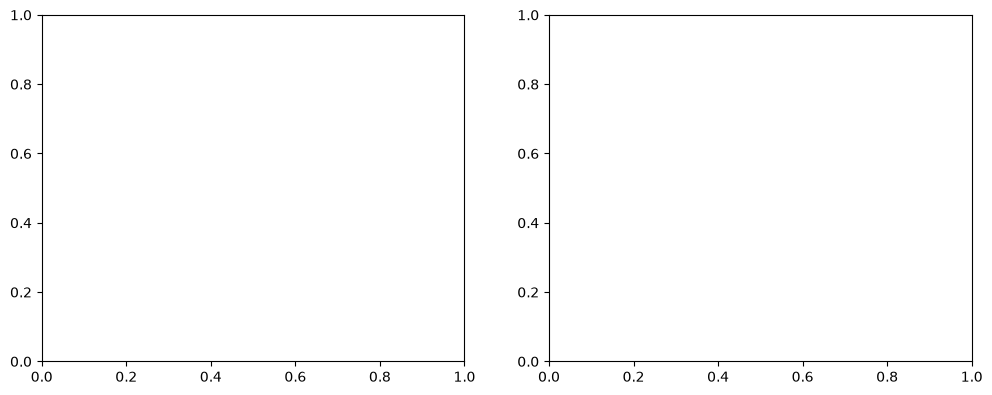

: 

In [ ]:
cols=['KSG']+[f'seed{s}' for s in SEEDS]+['surrogate']
data=[d_ksg]+[diffs_of(real[s]) for s in SEEDS]+[diffs_of(sur)]
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
ax[0].boxplot(data,labels=cols); ax[0].axhline(0,c='gray',lw=.8); ax[0].set_ylabel('TE(resp->heart)-TE(heart->resp), theo ban ghi')
for s in SEEDS: ax[1].scatter(d_ksg,diffs_of(real[s]),s=30,label=f'seed {s}')
ax[1].axhline(0,c='gray',lw=.8); ax[1].axvline(0,c='gray',lw=.8); ax[1].set_xlabel('KSG'); ax[1].set_ylabel('Thich nghi lr1e-3'); ax[1].legend()
plt.tight_layout(); plt.savefig(BASE/'results'/'figures'/'phase_u_adaptation_robustness.png',dpi=110); plt.show()

## 3. Kết luận G1' (tính từ số liệu)

In [ ]:
r=res[res.kind=='real']; s=res[res.kind=='surrogate'].iloc[0]
ok_corr=(r.spearman_vs_KSG>=0.3).all()
ok_sur=abs(s.mean_diff) < 0.5*r.mean_diff.mean()
print('Spearman vs KSG theo seed:', r.spearman_vs_KSG.tolist(), '-> moi seed >=0.3:', ok_corr)
print(f'Chenh TB that={r.mean_diff.mean():.4f} | surrogate={s.mean_diff:.4f} (dung chieu {s.frac_correct_dir:.2f}) -> surrogate nho hon 0.5x that: {ok_sur}')
print("G1':", 'QUA' if (ok_corr and ok_sur) else 'KHONG QUA')
print('Bao Claude ket qua; khong chinh sieu tham so de lam dep.')